# 04-Virtual Private Clouds (VPC) & Network Topologies

In Lesson 03, we engineered Event-Driven Storage using S3 and EventBridge. We built a system capable of handling petabytes of data securely and asynchronously.

However, where does the downstream compute (e.g., PySpark clusters, Airflow servers, or ML Inference APIs) physically reside? If you launch a server into the "default" cloud, it is exposed to the public internet. Malicious actors will continuously scan its IP address, executing brute-force attacks until they penetrate the system and deploy ransomware.

To survive in the Enterprise, you must engineer mathematical network isolation. You must build a **Virtual Private Cloud (VPC)**. A VPC utilizes Software-Defined Networking (SDN) to carve out a logically isolated, cryptographically secure slice of the AWS data center exclusively for your applications.

Let's boot our Boto3 engine targeting our LocalStack sandbox to engineer routing topologies from scratch for exactly $0.00.

In [1]:
# Required installations: pip install boto3 matplotlib seaborn ipaddress
import boto3
import ipaddress
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from botocore.exceptions import ClientError

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Virtual Network Topology Engine Initialized.")

✅ Systems Architecture & Virtual Network Topology Engine Initialized.


# 1. The Mathematics of CIDR (Classless Inter-Domain Routing)

To build a network, you must mathematically define the boundary of its IP addresses using **CIDR Notation**.
An IPv4 address is a 32-bit integer, typically represented as four 8-bit octets (e.g., `10.0.0.0`).

When creating a VPC, you assign a CIDR block, such as `10.0.0.0/16`.
The `/16` (the prefix) dictates exactly how many bits are "locked" for the network identity, and how many are free to assign to physical host machines (servers).


$$\text{Total IP Addresses} = 2^{32 - \text{prefix}}$$

For a `/16` VPC:


$$2^{32 - 16} = 2^{16} = 65,536 \text{ physical IP addresses}$$

### The Physics of Subnetting

A VPC spans an entire AWS Region, but physical servers exist inside specific Availability Zones (isolated concrete data centers). To place a server, you must fracture the VPC into **Subnets**.

If we create a Subnet with `10.0.1.0/24`:


$$2^{32 - 24} = 2^8 = 256 \text{ physical IP addresses}$$

**The AWS Subnet Tax:** AWS mathematically reserves exactly 5 IP addresses per subnet (Network Address, Router, DNS, Future Use, and Broadcast). Therefore, the usable IP space for your EC2 instances is always $2^{32 - N} - 5$.

Let's prove this topological math using Python.

In [2]:
# --- 🧮 Validating Network Physics ---
print("--- 🧮 Calculating Subnet Topologies ---")

vpc_cidr = ipaddress.IPv4Network("10.0.0.0/16")
subnet_public_cidr = ipaddress.IPv4Network("10.0.1.0/24")
subnet_private_cidr = ipaddress.IPv4Network("10.0.2.0/24")

print(f"VPC Boundary ({vpc_cidr}): {vpc_cidr.num_addresses:,} Total IPs")
print(f"Public Subnet ({subnet_public_cidr}): {subnet_public_cidr.num_addresses - 5} Usable Host IPs")
print(f"Private Subnet ({subnet_private_cidr}): {subnet_private_cidr.num_addresses - 5} Usable Host IPs")

# Mathematical Verification: Ensure subnets are strictly inside the VPC
if subnet_public_cidr.subnet_of(vpc_cidr) and subnet_private_cidr.subnet_of(vpc_cidr):
    print("✅ Subnets perfectly bounded within the VPC topological perimeter.")
else:
    print("❌ Mathematical routing violation detected.")

--- 🧮 Calculating Subnet Topologies ---
VPC Boundary (10.0.0.0/16): 65,536 Total IPs
Public Subnet (10.0.1.0/24): 251 Usable Host IPs
Private Subnet (10.0.2.0/24): 251 Usable Host IPs
✅ Subnets perfectly bounded within the VPC topological perimeter.


# 2. Imperative Execution: Boto3 Network Engineering (LocalStack)

Let's build a programmatic network locally. We need a VPC, a Public Subnet (for Load Balancers), an Internet Gateway (to allow mock internet traffic), and a Route Table to physically connect them.

Notice how Boto3 requires you to manually extract IDs and stitch the dependencies together, exposing the brittleness of imperative scripting.

In [3]:
# --- ⚙️ STEP 1: Initializing the EC2 Client (Network API Vector) ---
print("\n--- 🚀 Imperative Boto3 Network Provisioning (LocalStack) ---")

boto3.setup_default_session(aws_access_key_id='test', aws_secret_access_key='test', region_name='us-east-1')
local_endpoint = 'http://localhost:4566'

ec2_client = boto3.client('ec2', endpoint_url=local_endpoint)

try:
    # 1. Provision the VPC
    print("   [API CALL] Allocating VPC hardware...")
    vpc_response = ec2_client.create_vpc(CidrBlock='10.0.0.0/16')
    vpc_id = vpc_response['Vpc']['VpcId']
    
    # 2. Provision the Subnet
    print(f"   [API CALL] Carving Subnet out of {vpc_id}...")
    subnet_response = ec2_client.create_subnet(VpcId=vpc_id, CidrBlock='10.0.1.0/24')
    subnet_id = subnet_response['Subnet']['SubnetId']
    
    # 3. Provision the Internet Gateway (The Front Door)
    print("   [API CALL] Attaching Internet Gateway...")
    igw_response = ec2_client.create_internet_gateway()
    igw_id = igw_response['InternetGateway']['InternetGatewayId']
    ec2_client.attach_internet_gateway(VpcId=vpc_id, InternetGatewayId=igw_id)
    
    # 4. Engineer the Route Table (The Local Router)
    print("   [API CALL] Compiling Topological Routing Rules...")
    route_table_response = ec2_client.create_route_table(VpcId=vpc_id)
    route_table_id = route_table_response['RouteTable']['RouteTableId']
    
    # Mathematical Rule: Route all non-local traffic (0.0.0.0/0) to the IGW
    ec2_client.create_route(
        RouteTableId=route_table_id,
        DestinationCidrBlock='0.0.0.0/0',
        GatewayId=igw_id
    )
    
    # 5. Bind the Route Table to the Subnet (Making it mathematically "Public")
    ec2_client.associate_route_table(SubnetId=subnet_id, RouteTableId=route_table_id)
    
    print(f"   ✅ Local Network successfully engineered. Ready for mock EC2/Spark deployments.")

except ClientError as e:
    print(f"   [Error]: {str(e)[:100]}...")

print("\n--- 💡 Engineering Insight ---")
print("Look at the physical coupling required in Python. You must extract the `vpc_id` and explicitly pass it to the Subnet API. You must extract the `igw_id` and pass it to the Route Table API. If the Python script crashes at Step 3, you now have an orphaned VPC and Subnet that have no internet access. This violates the physics of infrastructure idempotency.")


--- 🚀 Imperative Boto3 Network Provisioning (LocalStack) ---
   [API CALL] Allocating VPC hardware...
   [API CALL] Carving Subnet out of vpc-921ee0e3...
   [API CALL] Attaching Internet Gateway...
   [API CALL] Compiling Topological Routing Rules...
   ✅ Local Network successfully engineered. Ready for mock EC2/Spark deployments.

--- 💡 Engineering Insight ---
Look at the physical coupling required in Python. You must extract the `vpc_id` and explicitly pass it to the Subnet API. You must extract the `igw_id` and pass it to the Route Table API. If the Python script crashes at Step 3, you now have an orphaned VPC and Subnet that have no internet access. This violates the physics of infrastructure idempotency.


# 3. Declarative Execution: Terraform Networking (LocalStack)

To engineer bulletproof, idempotent networks, Cloud Architects use Terraform. We define the state, and Terraform builds a **Dependency Graph** to compile the network in the exact optimal order.

Here is the declarative equivalent of the messy Python script above, strictly targeted at our $0.00 LocalStack environment.

```hcl
# --- 📜 network.tf (Declarative Network Topology) ---

provider "aws" {
  region                      = "us-east-1"
  access_key                  = "test"
  secret_key                  = "test"
  skip_credentials_validation = true
  skip_metadata_api_check     = true
  skip_requesting_account_id  = true

  endpoints {
    ec2 = "http://localhost:4566"
  }
}

# 1. Define the VPC Boundary
resource "aws_vpc" "enterprise_vpc" {
  cidr_block = "10.0.0.0/16"
  
  tags = {
    Name = "Local-Data-Engineering-VPC"
  }
}

# 2. Carve out a Public Subnet
resource "aws_subnet" "public_subnet" {
  vpc_id     = aws_vpc.enterprise_vpc.id  # Implicit Dependency Graphing
  cidr_block = "10.0.1.0/24"
}

# 3. Attach the Internet Gateway
resource "aws_internet_gateway" "igw" {
  vpc_id = aws_vpc.enterprise_vpc.id
}

# 4. Define the Routing Rules
resource "aws_route_table" "public_rt" {
  vpc_id = aws_vpc.enterprise_vpc.id

  route {
    cidr_block = "0.0.0.0/0"
    gateway_id = aws_internet_gateway.igw.id
  }
}

# 5. Bind the Rules to the Subnet
resource "aws_route_table_association" "public_binding" {
  subnet_id      = aws_subnet.public_subnet.id
  route_table_id = aws_route_table.public_rt.id
}

```

### The Physics of `aws_vpc.enterprise_vpc.id`

In Terraform, you do not hardcode IDs. When you reference `aws_vpc.enterprise_vpc.id` inside the Subnet resource, Terraform's compiler automatically calculates a **Directed Edge**. It proves mathematically that the VPC *must* be created before the Subnet. It resolves the `id` dynamically in memory at execution time.

# 4. Visualizing Network Isolation Topologies

To truly understand how a Private Subnet protects your Data Warehouse while a Public Subnet handles web traffic, let's use Python to map the topological flow of network packets inside our VPC.

/tmp/ipykernel_8826/2258087257.py:8: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0, 0.5), 13.5, 8, fill=True, color='#bdc3c7', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_8826/2258087257.py:12: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  vpc_box = patches.Rectangle((0.5, 1.0), 10.5, 6.5, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=2)
/tmp/ipykernel_8826/2258087257.py:17: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  pub_box = patches.Rectangle((1.0, 4.5), 9.5, 2.5, fill=True, color='#2ecc71', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='dashed')
/tmp/ipykernel_8826/2258087257.py:22: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  priv_box = patches.Rectangle((1.0, 1.5), 9.5, 2.5, fill

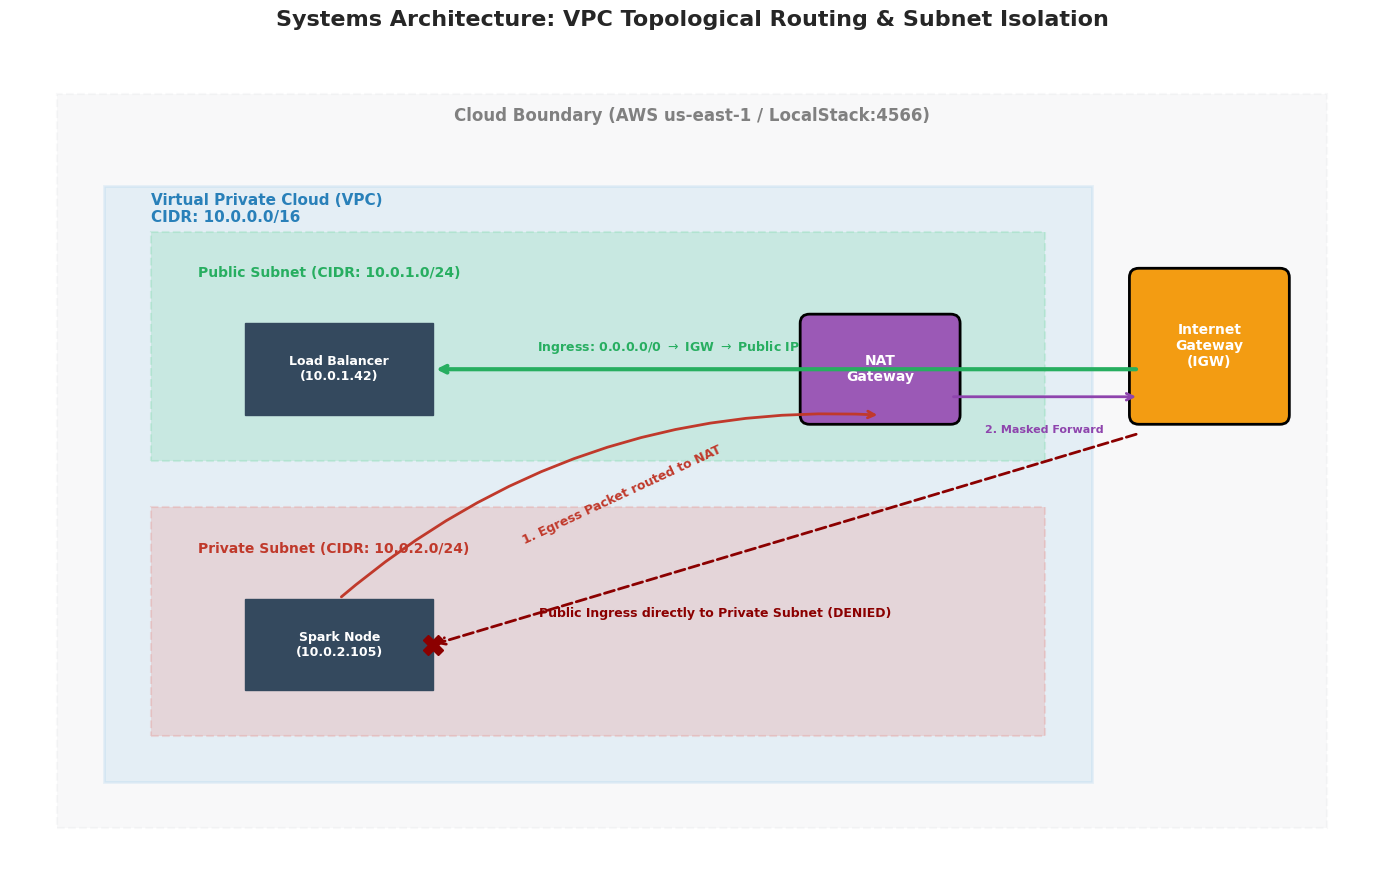

In [4]:
# Visualizing VPC Network Routing Topology
fig, ax = plt.subplots(figsize=(14, 9))
fig.suptitle("Systems Architecture: VPC Topological Routing & Subnet Isolation", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Global Cloud Boundary (Or LocalStack Boundary)
ax.add_patch(patches.Rectangle((0, 0.5), 13.5, 8, fill=True, color='#bdc3c7', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(6.75, 8.2, "Cloud Boundary (AWS us-east-1 / LocalStack:4566)", ha='center', color='gray', fontweight='bold', fontsize=12)

# 2. VPC Boundary (The SDN Perimeter)
vpc_box = patches.Rectangle((0.5, 1.0), 10.5, 6.5, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=2)
ax.add_patch(vpc_box)
ax.text(1.0, 7.1, "Virtual Private Cloud (VPC)\nCIDR: 10.0.0.0/16", ha='left', color='#2980b9', fontweight='bold', fontsize=11)

# 3. Public Subnet (The DMZ)
pub_box = patches.Rectangle((1.0, 4.5), 9.5, 2.5, fill=True, color='#2ecc71', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='dashed')
ax.add_patch(pub_box)
ax.text(1.5, 6.5, "Public Subnet (CIDR: 10.0.1.0/24)", ha='left', color='#27ae60', fontweight='bold', fontsize=10)

# 4. Private Subnet (The Secure Vault)
priv_box = patches.Rectangle((1.0, 1.5), 9.5, 2.5, fill=True, color='#e74c3c', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='dashed')
ax.add_patch(priv_box)
ax.text(1.5, 3.5, "Private Subnet (CIDR: 10.0.2.0/24)", ha='left', color='#c0392b', fontweight='bold', fontsize=10)

# 5. Gateways (The Doors)
# Internet Gateway
igw_box = patches.FancyBboxPatch((11.5, 5.0), 1.5, 1.5, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#f39c12')
ax.add_patch(igw_box)
ax.text(12.25, 5.75, "Internet\nGateway\n(IGW)", ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# NAT Gateway
nat_box = patches.FancyBboxPatch((8.0, 5.0), 1.5, 1.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#9b59b6')
ax.add_patch(nat_box)
ax.text(8.75, 5.5, "NAT\nGateway", ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# 6. Compute Nodes (EC2 / Spark)
# Application Load Balancer in Public
ax.add_patch(patches.Rectangle((2.0, 5.0), 2.0, 1.0, fill=True, color='#34495e', edgecolor='black'))
ax.text(3.0, 5.5, "Load Balancer\n(10.0.1.42)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# Database/Spark Cluster in Private
ax.add_patch(patches.Rectangle((2.0, 2.0), 2.0, 1.0, fill=True, color='#34495e', edgecolor='black'))
ax.text(3.0, 2.5, "Spark Node\n(10.0.2.105)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# 7. Routing Edges (The Physics of Packet Movement)
# Public Internet traffic hits IGW, routes to Load Balancer
ax.annotate("", xy=(4.0, 5.5), xytext=(11.5, 5.5), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60"))
ax.text(6.5, 5.7, "Ingress: 0.0.0.0/0 $\\rightarrow$ IGW $\\rightarrow$ Public IP", ha='center', fontweight='bold', color="#27ae60", fontsize=9)

# Spark Node needs to download a Python package (Egress)
ax.annotate("", xy=(8.75, 5.0), xytext=(3.0, 3.0), arrowprops=dict(arrowstyle="->", lw=2, color="#c0392b", connectionstyle="arc3,rad=-0.2"))
ax.text(6.0, 3.6, "1. Egress Packet routed to NAT", ha='center', fontweight='bold', color="#c0392b", fontsize=9, rotation=25)

# NAT Gateway masks the private IP and forwards to IGW
ax.annotate("", xy=(11.5, 5.2), xytext=(9.5, 5.2), arrowprops=dict(arrowstyle="->", lw=2, color="#8e44ad"))
ax.text(10.5, 4.8, "2. Masked Forward", ha='center', fontweight='bold', color="#8e44ad", fontsize=8)

# Security Group Denial Vector
ax.plot([4.0], [2.5], marker='X', markersize=15, color='darkred')
ax.annotate("", xy=(4.0, 2.5), xytext=(11.5, 4.8), arrowprops=dict(arrowstyle="->", lw=2, color="darkred", linestyle='dashed'))
ax.text(7.0, 2.8, "Public Ingress directly to Private Subnet (DENIED)", ha='center', fontweight='bold', color="darkred", fontsize=9)

plt.xlim(-0.5, 14.0)
plt.ylim(0, 9.0)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of a VPC like **The Architecture of an Exclusive Corporate Headquarters**:

* **The Public Internet (The Wild West)**: Anyone can walk down the street. It is dangerous and unpredictable.
* **The VPC (The Fence)**: You buy a plot of land and build a massive, 20-foot concrete wall around it. This mathematical boundary (CIDR block) guarantees physical isolation.
* **The Internet Gateway (The Front Gate)**: The only physical break in the concrete wall.
* **The Public Subnet (The Reception Lobby)**: Visitors (Web Traffic) enter through the Front Gate and walk into the Reception Lobby. They can talk to the Receptionist (The Load Balancer). The Receptionist is explicitly designed to handle the public safely.
* **The Private Subnet (The Underground Vault)**: The corporate executives and massive data mainframes (Spark Clusters / RDS Databases) sit in an underground vault with no doors to the outside world. They do not have Public IP addresses. A hacker on the internet mathematically cannot route a packet to them.
* **The NAT Gateway (The Secure Mailroom)**: If the mainframe needs to download a software update from the internet, it cannot walk out the front door. Instead, it drops a request in the internal mail chute. The Mailroom (NAT Gateway) sitting in the Public Subnet strips the mainframe's return address, slaps the Mailroom's public address on the envelope, and sends it out. When the software arrives, the Mailroom safely passes it back down the chute. The outside world never knows the mainframe exists.